In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm as norm
#Ax = b 

In [3]:
N = 20
delta = 0.05
eps = 1e-6
u0 = np.zeros(N)

def operator_A(N):
    A = np.ones((N, N))
    for j in range(N):
        for i in range(N):
            A[j,i] /= (i + 1) + (j + 1) - 1
    return A
u_exact = np.ones((N))

tau= 0.27493957337082653
|r_k+1|<=n*delta


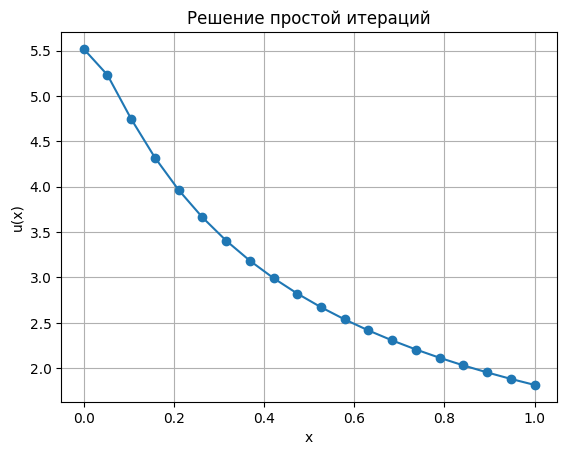

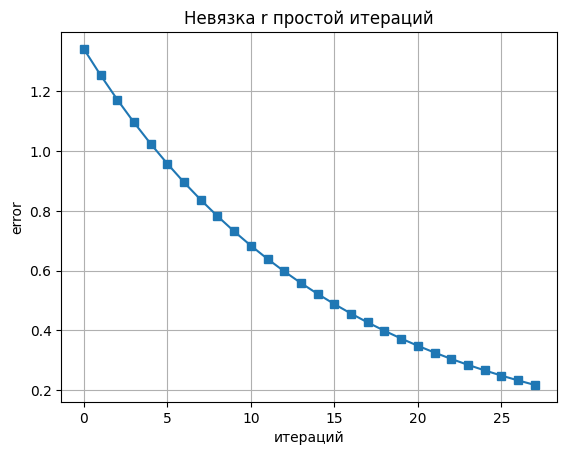

In [4]:
def simpleIter(A, b, tau, u0):
    N = len(b)
    uk = np.zeros((N))
    max_iter = 100
    r_log = []
    for i in range(max_iter):
        uk = tau * b - tau * A.dot(u0) + u0
        r = A.dot(uk)-b
        r_log.append(norm(r)) 
        if (norm(r)<= np.sqrt(N)*delta):
            print("|r_k+1|<=n*delta")
            return r_log, uk
        u0 = uk.copy()
    print("достиг 100 итераций")
    return r_log, uk
    
A = operator_A(N)
b = np.zeros(N)
for i in range(N):
    sumA = 0
    for j in range(N):
        sumA += A[i][j]
    b[i] = sumA 

x = np.linspace(0, 1, N)
sigma = np.random.normal(N)*2-1

b_delta = b + delta * sigma

A = A @ A.T
b_delta = b_delta @ A.T

eig_values, eig_vector = np.linalg.eig(A)
tau = 1 / eig_values.max()
print("tau=", tau)
r_log, y = simpleIter(A, b_delta,tau, u0)

plt.figure()
plt.title("Решение простой итераций"); plt.xlabel("x"); plt.ylabel("u(x)"); plt.grid()
plt.plot(x, y, marker="o")

plt.figure()
plt.plot(r_log, marker="s")
plt.title("Невязка r простой итераций"); plt.xlabel("итераций"); plt.ylabel("error"); plt.grid()
plt.show()

tau= 0.27493957337082653
|r_k+1|<=n*delta


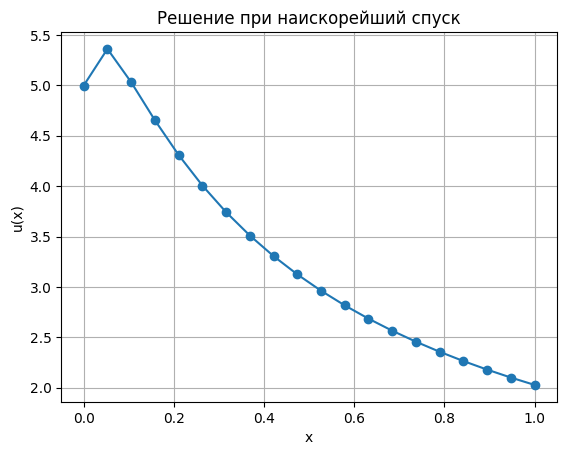

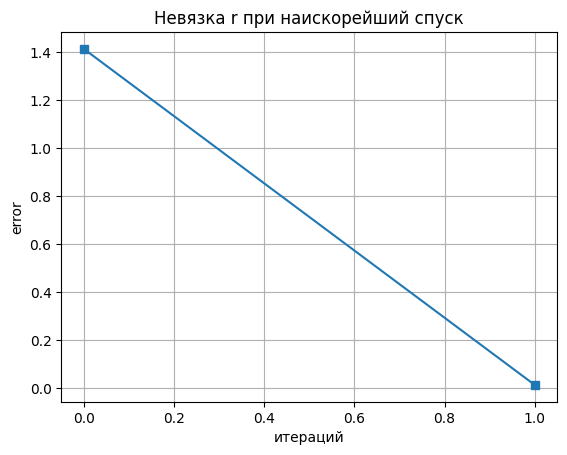

In [5]:
def SpeedyDescentIter(A, b, tau, u0):
    N = len(b)
    uk = np.zeros((N))
    max_iter = 100
    r_log = []
    for i in range(max_iter):
        uk = tau * b - tau * A.dot(u0) + u0
        r = A.dot(uk)-b
        r_log.append(norm(r)) 
        if (norm(r)<= np.sqrt(N)*delta):
            print("|r_k+1|<=n*delta")
            return r_log, uk
        u0 = uk.copy()
        tau = r.dot(r)/(A.dot(r)).dot(r)
    print("достиг 100 итераций")
    return r_log, uk



A = operator_A(N)
b = np.zeros(N)
for i in range(N):
    sumA = 0
    for j in range(N):
        sumA += A[i][j]
    b[i] = sumA 

x = np.linspace(0, 1, N)
sigma = np.random.normal(N)*2-1

b_delta = b + delta * sigma

A = A @ A.T
b_delta = b_delta @ A.T
eig_values, eig_vector = np.linalg.eig(A)

tau = 1/eig_values.max()
print("tau=", tau)
r_log, y = SpeedyDescentIter(A, b_delta,tau, u0)

plt.figure()
plt.title("Решение при наискорейший спуск"); plt.xlabel("x"); plt.ylabel("u(x)"); plt.grid()
plt.plot(x, y, marker="o")

plt.figure()
plt.plot(r_log, marker="s")
plt.title("Невязка r при наискорейший спуск"); plt.xlabel("итераций"); plt.ylabel("error"); plt.grid()
plt.show()

tau= 0.27493957337082653
|r_k+1|<=n*delta


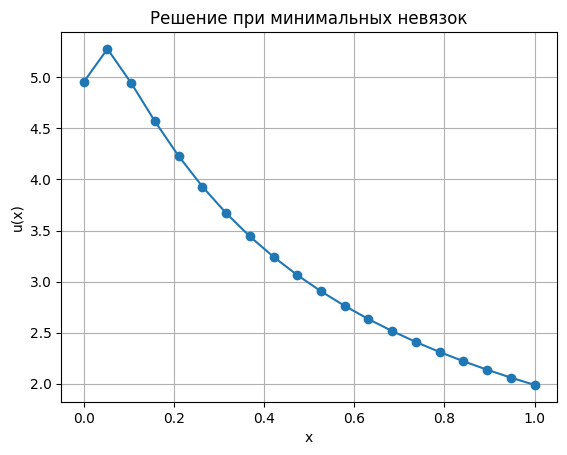

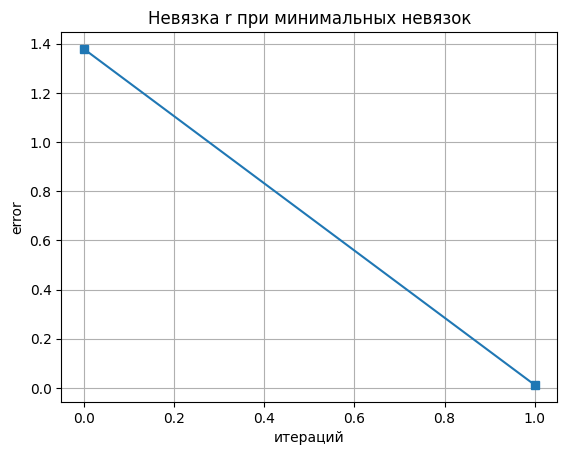

In [10]:

def MinResidualIter(A, b, tau, u0):
    N = len(b)
    uk = np.zeros((N))
    max_iter = 100
    r_log = []
    for i in range(max_iter):
        uk = tau * b - tau * A.dot(u0) + u0
        r = A.dot(uk)-b
        r_log.append(norm(r)) 
        if (norm(r)<= np.sqrt(N)*delta):
            print("|r_k+1|<=n*delta")
            return r_log, uk
        u0 = uk.copy()
        tau = (A @ r).dot(r) / (A @ r).dot(A @ r)
    print("достиг 100 итераций")
    return r_log, uk



A = operator_A(N)
b = np.zeros(N)
for i in range(N):
    sumA = 0
    for j in range(N):
        sumA += A[i][j]
    b[i] = sumA 

x = np.linspace(0, 1, N)
sigma = np.random.normal(N) *2-1

b_delta = b + delta * sigma

A = A @ A.T
b_delta = b_delta @ A.T
eig_values, eig_vector = np.linalg.eig(A)

tau = 1/eig_values.max()
print("tau=", tau)
r_log, y = MinResidualIter(A, b_delta,tau, u0)

plt.figure()
plt.title("Решение при минимальных невязок"); plt.xlabel("x"); plt.ylabel("u(x)");plt.grid()
plt.plot(x, y, marker="o")

plt.figure()
plt.plot(r_log, marker="s")
plt.title("Невязка r при минимальных невязок"); plt.xlabel("итераций"); plt.ylabel("error"); plt.grid()
plt.show()